# Black Friday Sales Analysis
## Problem Statement
Predict how much a customer spends on Black Friday, using customer and product details.

This is **regression**: the target is a dollar amount, not Yes/No.


## Objectives
1. Find which factors change how much people spend
2. Build models that predict purchase amount
3. Compare different regression models
4. Turn the results into simple marketing ideas


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load and inspect data
df = pd.read_csv('BlackFriday.csv')
print(f"Dataset dimensions: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset dimensions: (537577, 12)

First 5 rows:


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969



Data types:
User_ID                         int64
Product_ID                        str
Gender                            str
Age                               str
Occupation                      int64
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

Missing values:
User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64


### Feature Classification
- **Categorical** (labels): User_ID, Product_ID, Gender, Age, Occupation, City_Category, Stay_In_Current_City_Years, Marital_Status, Product_Category_1/2/3
- **Continuous** (a number): Purchase (what we predict)


### Categorical Variables Analysis

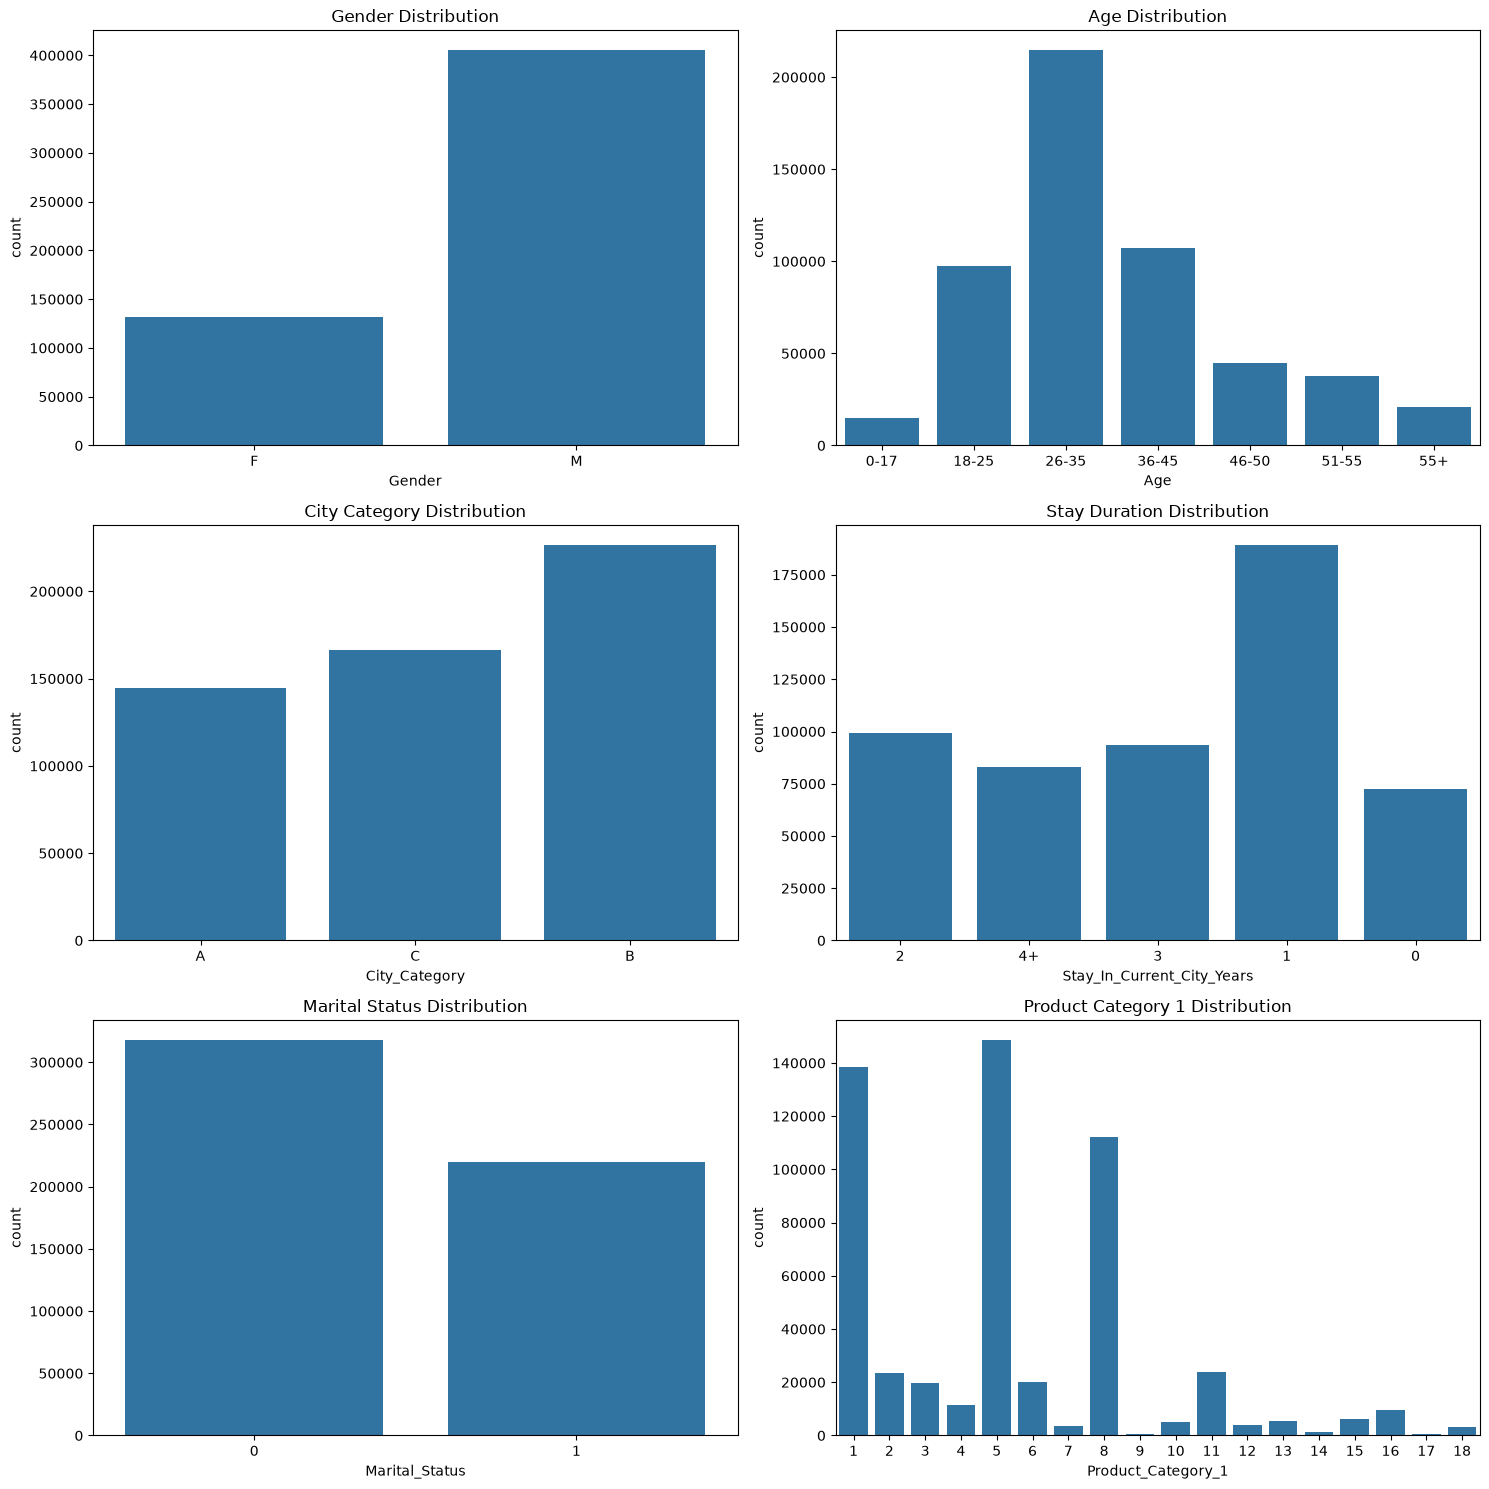

In [3]:
# Visualize categorical distributions
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Gender distribution
sns.countplot(x='Gender', data=df, ax=axes[0,0])
axes[0,0].set_title('Gender Distribution')

# Age distribution
sns.countplot(x='Age', data=df, ax=axes[0,1], order=sorted(df['Age'].unique()))
axes[0,1].set_title('Age Distribution')

# City category
sns.countplot(x='City_Category', data=df, ax=axes[1,0])
axes[1,0].set_title('City Category Distribution')

# Stay in current city
sns.countplot(x='Stay_In_Current_City_Years', data=df, ax=axes[1,1])
axes[1,1].set_title('Stay Duration Distribution')

# Marital status
sns.countplot(x='Marital_Status', data=df, ax=axes[2,0])
axes[2,0].set_title('Marital Status Distribution')

# Product category 1
sns.countplot(x='Product_Category_1', data=df, ax=axes[2,1])
axes[2,1].set_title('Product Category 1 Distribution')

plt.tight_layout()
plt.show()

### Continuous Variables Analysis

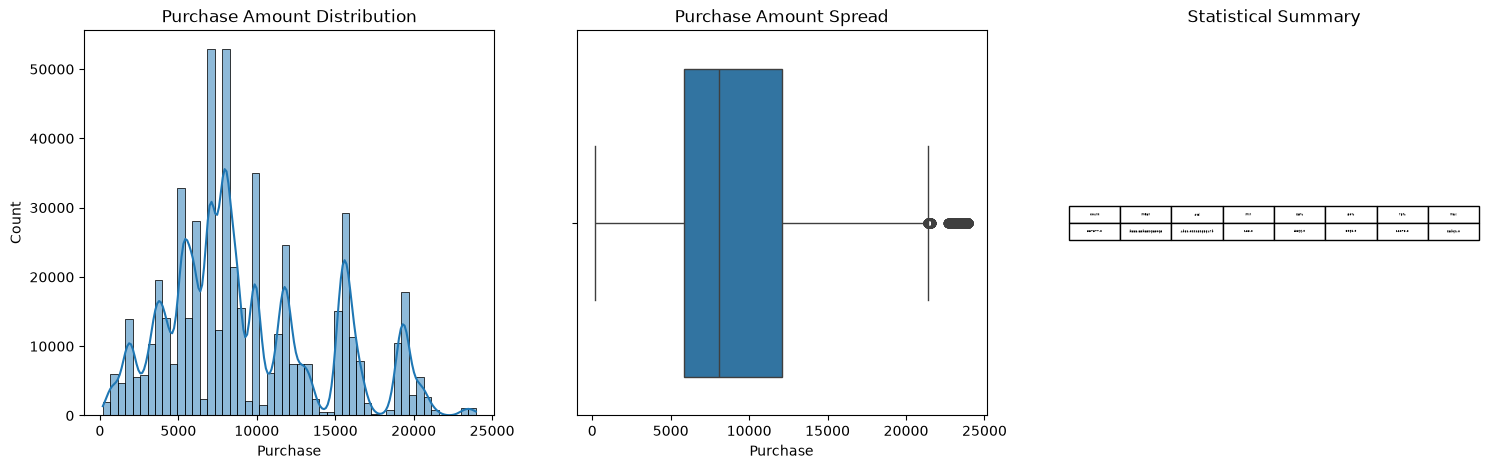

In [4]:
# Purchase amount analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
sns.histplot(df['Purchase'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Purchase Amount Distribution')

# Boxplot
sns.boxplot(x=df['Purchase'], ax=axes[1])
axes[1].set_title('Purchase Amount Spread')

# Statistical summary
stats = df['Purchase'].describe().to_frame().T
axes[2].axis('off')
axes[2].table(cellText=stats.values, 
             colLabels=stats.columns, 
             loc='center',
             cellLoc='center')
axes[2].set_title('Statistical Summary')

plt.show()

### Data Preprocessing

In [5]:
# Missing extra product categories: -1 means "this product has no 2nd/3rd category"
df['Product_Category_2'] = df['Product_Category_2'].fillna(-1)
df['Product_Category_3'] = df['Product_Category_3'].fillna(-1)

# IQR outlier rule: drop purchases that are far below Q1 or far above Q3
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['Purchase'] >= lower) & (df['Purchase'] <= upper)]

# Turn text labels into numbers (e.g. Gender F/M -> 0/1)
cat_cols = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Feature selection
features = ['Gender', 'Age', 'Occupation', 'City_Category',
            'Stay_In_Current_City_Years', 'Marital_Status',
            'Product_Category_1', 'Product_Category_2', 'Product_Category_3']

# Use a sample so training finishes faster (remove this limit for the full dataset)
selection_set = 100000
X = df[features][:selection_set]
y = df['Purchase'][:selection_set]

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale so each feature has mean ~0 and std ~1 (helps SVR and the Neural Net)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Selection
**Why these models**:
1. **Random Forest**: works with mixed data; not easily thrown off by outliers
2. **SVR**: a different method from trees, useful as a comparison
3. **Neural Network (MLP)**: can learn more complex spend patterns


In [6]:
# Initialize models
# Random Forest: many decision trees; the final prediction is their average
#   n_estimators = number of trees (more trees = more stable, but slower)
#   random_state = fixed seed so you get the same result each run
# SVR: fits a "tube" around the purchase amounts (good for non-linear patterns)
#   kernel='rbf' = radial basis function; maps data so a curve can be learned
#   C = how strictly we fit the training data (larger C = less error allowed)
#   gamma = how far one training point's influence reaches (larger = more local)
# Neural Network: stacked layers of neurons that learn non-linear relationships
#   hidden_layer_sizes=(50, 25) = two hidden layers, 50 neurons then 25
#   max_iter = max training passes through the data
#   random_state = fixed seed for the starting weights
models = {
    'Random Forest': RandomForestRegressor(n_estimators=10, random_state=42),
    'Support Vector Regression': SVR(kernel='rbf', C=10, gamma=0.1),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
}

# Train and evaluate
results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

# Display results
results_df = pd.DataFrame(results).T
display(results_df)

/home/cbah/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,MAE,RMSE,R2
Random Forest,2349.858424,3208.450550,0.569954
Support Vector Regression,3214.610509,4258.533644,0.242393
Neural Network,2458.770151,3253.757241,0.557723


### Predicted vs Actual
Each point is one test purchase. The dashed line is a perfect prediction (predicted = actual). Points closer to that line mean the model did better.


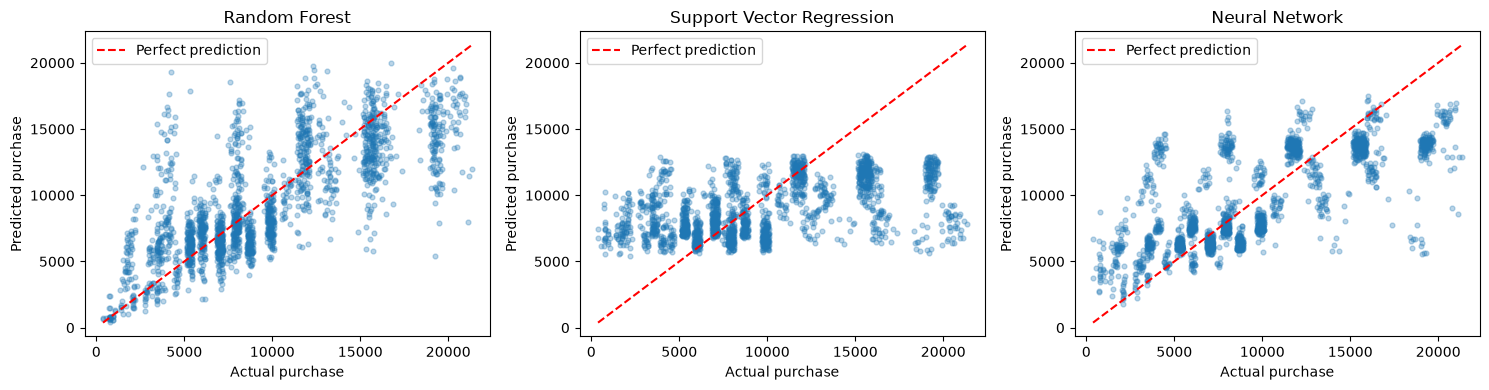

In [7]:
# Predicted vs actual: dots near the red line mean the model is close
# Plot a sample so the scatter stays readable
n_plot = 2000
y_true = y_test.iloc[:n_plot]

plt.figure(figsize=(15, 4))
for i, name in enumerate(predictions):
    y_hat = predictions[name][:n_plot]
    plt.subplot(1, 3, i + 1)
    plt.scatter(y_true, y_hat, alpha=0.3, s=12)
    # Dashed line: predicted = actual
    lo = min(y_true.min(), y_hat.min())
    hi = max(y_true.max(), y_hat.max())
    plt.plot([lo, hi], [lo, hi], 'r--', label='Perfect prediction')
    plt.xlabel('Actual purchase')
    plt.ylabel('Predicted purchase')
    plt.title(name)
    plt.legend()
plt.tight_layout()
plt.show()

### Evaluation Metrics Explanation
- **MAE**: on average, how many dollars we are off
- **RMSE**: like MAE, but big mistakes count more
- **R²**: how much of the spend pattern the model explains (1 is perfect; 0 is no better than guessing the average)


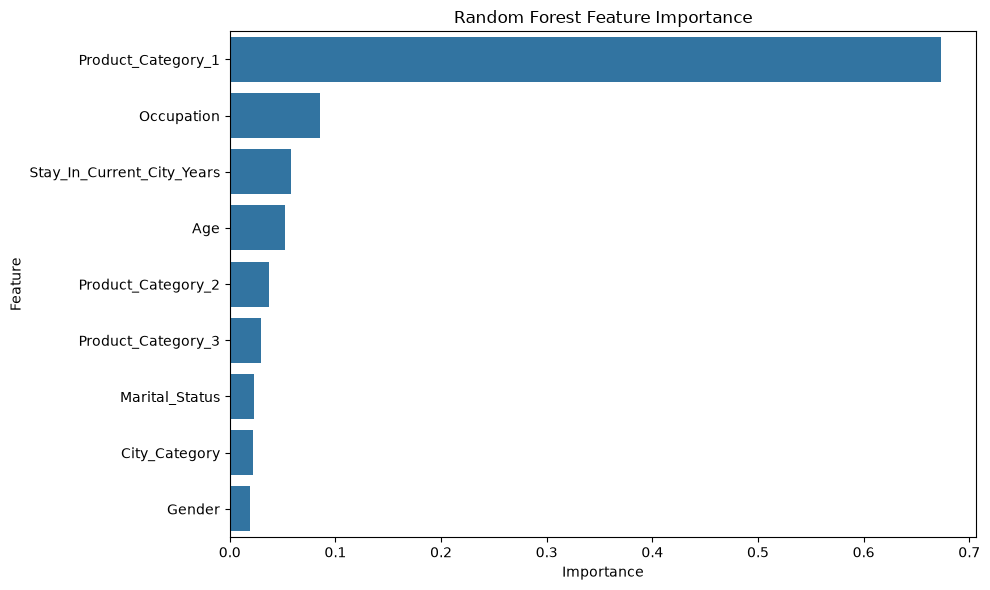

In [8]:
# Feature importance visualization (Random Forest example)
rf = models['Random Forest']
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning (GridSearch)

GridSearch tries several settings and keeps the combination with the best score.

- This is a **regression** problem, so the score is **R²** (higher is better).
- We search a small grid so the cell finishes in a lab session:
  - `n_estimators` = number of trees
  - `max_depth` = how deep each tree can grow
  - `min_samples_split` = how many rows are needed to split a node

After the search, we retrain the best settings on the full training set and test them.


In [9]:
# Try these settings. GridSearch will test every combination.
param_grid = {
    'n_estimators': [10, 30],       # number of trees
    'max_depth': [8, 16],           # how deep each tree can grow
    'min_samples_split': [2, 5]     # min rows needed to split a node
}

# Use a smaller sample so the search finishes quickly (2 x 2 x 2 x 3 folds)
gs_n = 8000
X_gs = X_train_scaled[:gs_n]
y_gs = y_train.iloc[:gs_n]

# scoring='r2' because this is a regression problem (purchase amount)
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='r2',
    cv=3,       # 3-fold cross-validation
    n_jobs=-1
)
rf_search.fit(X_gs, y_gs)

print('Best hyperparameters:', rf_search.best_params_)
print('Best CV R2:', round(rf_search.best_score_, 3))

# Train the winning settings on the full training set, then score on test data
best_rf = rf_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)
y_pred_gs = best_rf.predict(X_test_scaled)

print('\nTuned Random Forest on the test set:')
print('MAE:', round(mean_absolute_error(y_test, y_pred_gs), 3))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_gs)), 3))
print('R2:', round(r2_score(y_test, y_pred_gs), 3))


Best hyperparameters: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 30}
Best CV R2: 0.611

Tuned Random Forest on the test set:
MAE: 2227.23
RMSE: 2937.516
R2: 0.64


### Feature Importance Analysis (SHAP)

SHAP shows **how** each feature pushes a predicted purchase **up or down**.
The forest's own ranking only lists features. SHAP also shows the **direction**.

We explain a sample of test rows because the full test set would be slow.

If needed: `pip install shap`


In [ ]:
import shap

# Explain 200 test rows (the full test set would be slow)
shap_n = 200
X_shap = pd.DataFrame(X_test_scaled[:shap_n], columns=features)

# TreeExplainer is the fast SHAP method for Random Forest
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

print('SHAP values shape:', np.shape(shap_values))
# Dots to the right mean the feature increased the predicted purchase amount
shap.summary_plot(shap_values, X_shap, show=True)

# Average |SHAP|: bigger number = more important overall
mean_abs = np.abs(shap_values).mean(axis=0)
shap_rank = pd.DataFrame({
    'Feature': features,
    'mean_abs_SHAP': mean_abs
})
shap_rank = shap_rank.sort_values('mean_abs_SHAP', ascending=False)
display(shap_rank.head(10))


ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

## Final Discussion Questions

**1. How did feature importance differ between regression and classification?**

- **Retail (this notebook) is regression.** It predicts a number: how much a customer spends.
  Important features change the **dollar amount**.
  SHAP ranks `Product_Category_1` far above the rest. Next are `City_Category` and the other product categories. Age and Occupation matter less. Gender and marital status barely move the predicted spend.

- **Weather is classification.** It predicts Yes/No: will it rain tomorrow?
  Important features help tell **rain apart from no rain**.
  Afternoon humidity, rainfall, wind, cloud, pressure, and `RainToday` matter most.

- **SHAP meaning:** here, a feature pushes predicted **spend** up or down. In weather, a feature pushes the **chance of rain** up or down.

**2. Which evaluation metrics were most appropriate for each problem?**

- **Retail:** use **MAE**, **RMSE**, and **R²**. These ask: "How far is the predicted spend from the real spend?" GridSearch also used R².
- **Weather:** use **precision**, **recall**, **F1**, and a **confusion matrix**. Only about 21% of days are rain days, so a model can get high **accuracy** by mostly saying "No" and still miss many rain days. The >75% accuracy goal is still useful, but it is not enough on its own.

**3. What data quality issues appeared in both datasets?**

- **Retail:** many missing `Product_Category_2` and `Product_Category_3` values (filled with -1). Purchase amounts have outliers. `User_ID` and `Product_ID` should not be used as ordinary numbers.
- **Weather:** Sunshine, Evaporation, and Cloud have a lot of missing values (about 40-55%). Some rows have no `RainTomorrow` label. Rain days are the smaller class (about 21%). `RISK_MM` must be dropped because it already contains tomorrow's rainfall (that would be cheating).
- **Both:** fill missing values using **training data only**, then apply the same rule to the test data.

**4. How would you improve either analysis, given more time?**

- **Retail:** train on all rows (not only 100,000), search on more than 8,000 rows, add XGBoost or LightGBM, add features about a user's past purchases, and tune SVR and the neural network (their default settings did not fit well).
- **Weather:** train on all rows, split by **date** (not randomly), add a flag for missing Sunshine/Cloud, try a larger GridSearch, and choose a threshold that catches more rain days (not always 0.5).


## Insights and Conclusions

1. **Key findings**
   - **Best default model:** Random Forest (MAE about $2,350, RMSE about $3,208, R² 0.57). The neural network is close (R² 0.56). SVR is much worse (R² 0.24).
   - **Tuning helped.** GridSearch on Random Forest found `n_estimators=30`, `max_depth=8`, `min_samples_split=5`. On the test set this raised R² from 0.57 to **0.64** and cut MAE to about **$2,227**.
   - **What drives spend (SHAP):** `Product_Category_1` dominates. Then `City_Category`, then `Product_Category_2` and `Product_Category_3`. Age and Occupation matter some. Gender and marital status barely change the predicted amount.

2. **Business implications**
   - The **product category** is the main lever. Focus stock and ads on high-value categories.
   - **City type** also changes spend, so offers can differ by city category.
   - Age and job type matter less than the product itself, so they are secondary for targeting.

3. **Model limitations**
   - Models used a **100,000-row sample**, not the full file. GridSearch used only **8,000** training rows.
   - **SVR** did the worst. Its settings were not a good fit.
   - The **neural network** hit the 500-iteration limit and had not finished learning.
   - Extra product categories were filled with **-1**, which simply means "no second/third category".

4. **Future work**
   - Train on all rows, and search settings on a larger sample.
   - Try **XGBoost** or **LightGBM**, and tune SVR and the neural network.
   - Add features about a user's past purchases, and look at time patterns (weekends, payday, seasons).
